# Imports

In [1]:
import os
import sys

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [3]:
import frank2d
from frank2d import Frank2D, Geometry, rad_to_arcsec, Plot

### Load data

In [6]:

dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }


In [7]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


#### Power spectrum

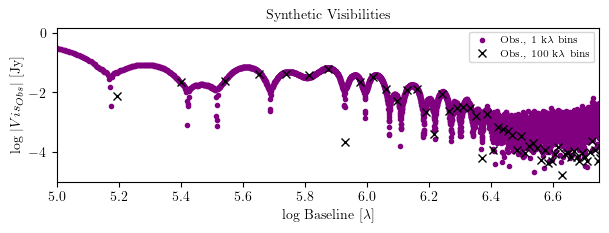

In [8]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, marker=ms[0], ls='None', c ='purple', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Synthetic Visibilities", size = 10)
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

### Dirty image

In [9]:
frank2d0 = Frank2D(N, Rmax, use_gpu=True)

In [10]:
frank2d0.dx

0.009345794392523364

In [11]:
q_min_f2d = np.unique(np.sort(np.hypot(frank2d0.u, frank2d0.v)))[1]
q_max_f2d = np.unique(np.sort(np.hypot(frank2d0.u, frank2d0.v)))[-1]
print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min frank2d: 48617.081072483736, q_max frank2d: 15606083.024267279
-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [12]:
np.sort(frank2d0.FT.q)

array([       0.        ,    34377.46770785,    34377.46770785, ...,
       15581793.44513957, 15581793.44513957, 15606083.02426728],
      shape=(412164,))

In [13]:
frank2d0.process_vis(uvtable)

===>  Setting gridded data...


In [14]:
u, v = frank2d0.gridded_data['u'].get(), frank2d0.gridded_data['v'].get()
vis = frank2d0.gridded_data['vis'].get()
weights = frank2d0.gridded_data['weights']

In [15]:
zoom_factor =1.5

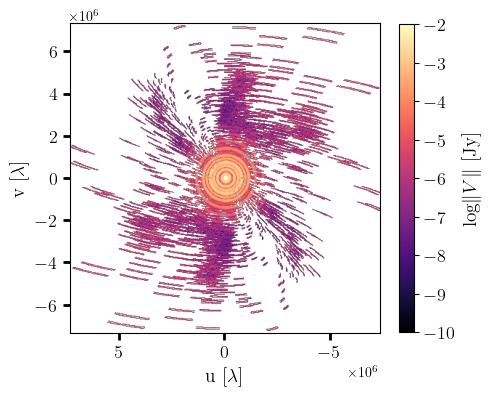

In [16]:
plt.figure(figsize=(5,5))
plt.imshow(np.log(np.abs(vis.reshape(N,N))), 
            extent = [u.max(), u.min(), v.min(), v.max()],
            cmap = 'magma', 
             vmin=-10, vmax=-2)


#plt.title('Synthetic visibilities', size=10)
plt.ylim(v.min()/zoom_factor, v.max()/zoom_factor)
plt.xlim(u.max()/zoom_factor, u.min()/zoom_factor)
plt.xlabel(r'u [$\lambda$]', size=14, weight='extra bold')
plt.ylabel(r'v [$\lambda$]', size=14, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(r'log$\| V \|$ [Jy]', size=14)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)
plt.show() # Asegúrate de tener esta línea si no usas notebooks

In [17]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis.reshape(N,N)))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

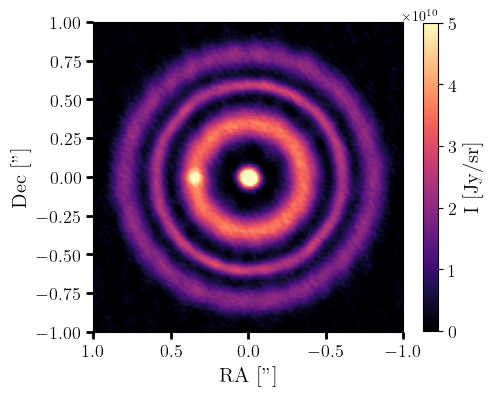

In [18]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmax=5e10, vmin = 0)
plt.figure(figsize=(5,5))
plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma',
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
#plt.title('Mock data', size =10)
plt.xlabel(r'RA ["]', size=15, weight='extra bold')
plt.ylabel('Dec ["]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(label='I [Jy/sr]', size=15)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)

### Frank2D

In [19]:
geom = Geometry(0, 0, 0, 0)

In [20]:
N

642

In [21]:
Rmax

3

In [22]:
frank2d2 = Frank2D(N, Rmax)

In [23]:
frank2d2.dx

0.009345794392523364

In [24]:
frank2d2.process_vis(uvtable)

===>  Setting gridded data...


In [25]:
frank2d2.fit( rtol = 1e-10)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
Updating m to  -2
Updating c to  100000000.0
Updating l to  50000.0
===>  Creating sparse linear system...


        +  Kernel = 0.03  min |  1.56 seconds
        +  Building system = 0.03  min |  1.61 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 243/50000 [00:19<1:04:52, 12.78 iterations/s]


            +  BiCGStab = 0.32  min |  19.04 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417658,
 'iterations': 243,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
Updating m to  -2
Updating c to  100000000.0
Updating l to  50000.0
     + Setting kernel..
Updating m to  -2
Updating c to  100000000.0
Updating l to  50000.0
--> time building S_12_T = 0.10  min |  5.79 seconds
--> times building full visibility model = 0.10  min |  5.82 seconds


In [17]:
frank2d2.fit(data = uvtable, rtol = 1e-10)

===>  Creating sparse linear system...


KeyboardInterrupt: 

In [35]:
Plot_ = Plot(frank2d2, geom)

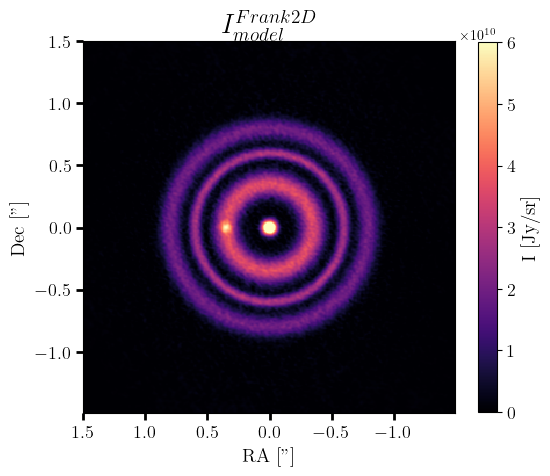

In [36]:
Plot_.intensity(vmax=6e10, gamma = 1, zoom = 2, title = r'$I_{model}^{Frank2D}$')

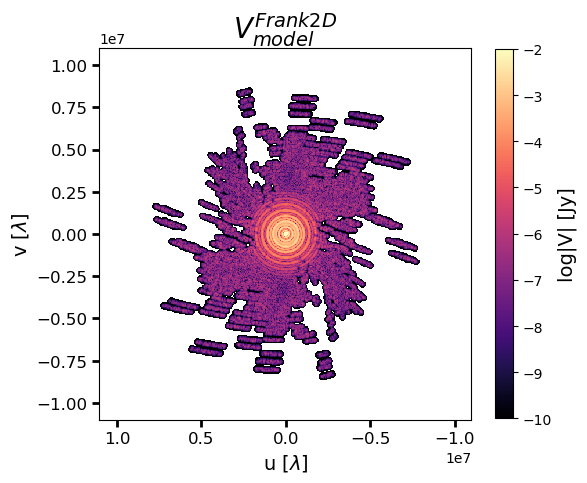

In [21]:
Plot_.visibility(fig_size=6, title= r'$V_{model}^{Frank2D}$')

###  Best

In [68]:
initial_guess = {'p': -1, 'm': -1, 'logl': 4}

In [69]:
frank2d2.search_MAP(initial_guess= initial_guess, N = 50)

Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 287.91 seconds
--> Calculating m_log_posterior with m, logc, logl: 0 -2.0 4.0
----------- m_log_post: -1015300988.6032605 -----------
Setting the initial guess...
 + Initial guess for the parameters (p, m, l): [-1.0, -1.0, 10000.0]
--> Calculating m_log_posterior with m, logc, logl: -1.0 4.0 4.0
----------- m_log_post: -1015300727.1926627 -----------
 + Initial guess for the parameters (p, m, l): [-2.0, -2.0, 10000.0]
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1015303604.3748907 -----------
Optimizing the posterior...
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1015303604.3748907 -----------
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.1 4.0
----------- m_log_post: -1015303786.9453533 -----------
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.2618034 4.0
----------- m_log_post: -1015303886.3244125 -----------
--> Calculating m_lo

In [70]:
frank2d2.MAP

{'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

### Frank2D with best values

In [28]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

In [29]:
frank2d3 = Frank2D(N, Rmax)

In [30]:
frank2d3.process_vis(uvtable)

===>  Setting gridded data...


In [31]:
frank2d3.fit(kernel_params = best_N50, rtol = 1e-10) # 1m7s

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...


        +  Kernel = 0.10  min |  5.79 seconds
        +  Building system = 0.10  min |  5.95 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [01:07<3:20:24,  4.14 iterations/s]


            +  BiCGStab = 1.13  min |  67.59 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.19  min |  11.59 seconds
--> times building full visibility model = 0.19  min |  11.64 seconds


In [32]:
#frank2d3.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10) # 1m7s

In [36]:
Plot_3 = Plot(frank2d3, geom)

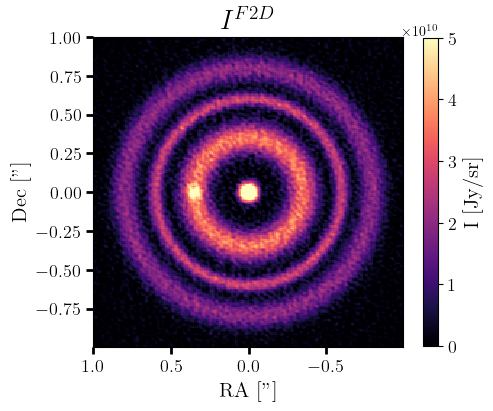

In [37]:
Plot_3.intensity(vmax=5e10, gamma = 1, zoom = 3, title = r'$I^{F2D}$', fig_size=5, label_size=15)

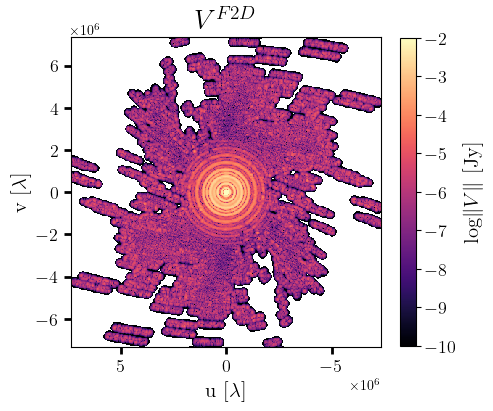

In [38]:
Plot_3.visibility(fig_size=5, zoom = 1.5, vmin = -10,  title = r'$V^{F2D}$', label_size=15)

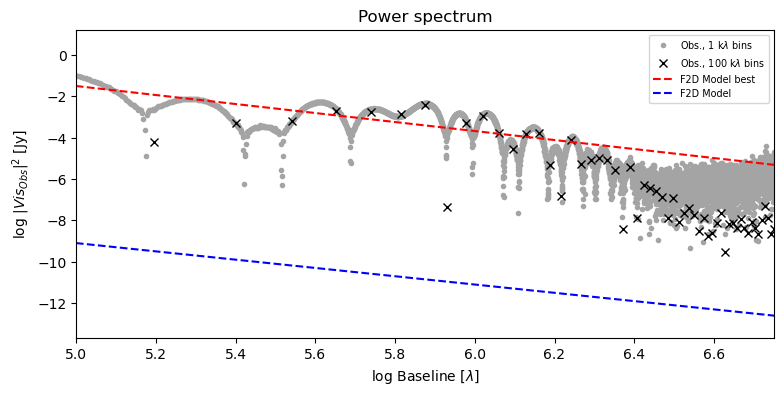

In [17]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

lgy_best = linear_power_spectrum(lgx, best_N50['m'], best_N50['c'])
lgy_ = linear_power_spectrum(lgx,-2, 8)

plt.plot(lgx, lgy_best, 'r--', label='F2D Model best')
plt.plot(lgx, lgy_, 'b--', label='F2D Model')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()